"""
# Customer Churn Analysis and Prediction

This project analyzes a telecom company's customer data to understand factors influencing churn and build models to predict it.

**Data Overview**
- Dataset contains customer demographics, services subscribed, and payment information.
- Key target: `Churn` (Yes/No).

**Exploratory Data Analysis**
- Checked for missing values and data types.
- Investigated categorical columns with counts and proportions.
- Visualized relationships between features and `Churn` using stacked bar charts and histograms.
- Examined distributions of `tenure`, `MonthlyCharges`, and `TotalCharges`.

**Preprocessing**
- Removed `customerID` and cleaned `TotalCharges`.
- Encoded categorical features and scaled numerical features as needed.
- Split data into train and test sets with stratification on `Churn`.

**Modeling**
- Trained `LogisticRegression`, `SVC`, `DecisionTree`, `RandomForest`, and `AdaBoost` classifiers.
- Evaluated models using `Accuracy`, `Recall`, and `ROC-AUC`.

**Observations**
- `LogisticRegression` had the highest recall among tested models.
- `AdaBoost` achieved slightly higher ROC-AUC.
- Recall is emphasized because catching actual churners is more relevant than overall accuracy.

"""


In [125]:
import pandas as pd
import matplotlib.pyplot as plt

In [82]:
df = pd.read_csv('Dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Overview of Data

In [83]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [84]:
df.iloc[:,-1].unique() #binary classification

array(['No', 'Yes'], dtype=object)

In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [88]:
def information(df):
    for cols in df.columns:
        if df[cols].dtypes == 'object':
            print(f'{cols}: ',df[cols].unique())
        else:
            print(f'{cols}: is not categorical',)
        
# one mistake that i noticed here is that TotalCharges column is being considered as object type whereas it should be float type.. so i will investigate that now

In [89]:
information(df)

customerID:  ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
gender:  ['Female' 'Male']
SeniorCitizen: is not categorical
Partner:  ['Yes' 'No']
Dependents:  ['No' 'Yes']
tenure: is not categorical
PhoneService:  ['No' 'Yes']
MultipleLines:  ['No phone service' 'No' 'Yes']
InternetService:  ['DSL' 'Fiber optic' 'No']
OnlineSecurity:  ['No' 'Yes' 'No internet service']
OnlineBackup:  ['Yes' 'No' 'No internet service']
DeviceProtection:  ['No' 'Yes' 'No internet service']
TechSupport:  ['No' 'Yes' 'No internet service']
StreamingTV:  ['No' 'Yes' 'No internet service']
StreamingMovies:  ['No' 'Yes' 'No internet service']
Contract:  ['Month-to-month' 'One year' 'Two year']
PaperlessBilling:  ['Yes' 'No']
PaymentMethod:  ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
MonthlyCharges: is not categorical
TotalCharges:  ['29.85' '1889.5' '108.15' ... '346.45' '306.6' '6844.5']
Churn:  ['No' 'Yes']


### Problem detected in TotalCharges column  
why is it object type??

In [90]:
df[df['TotalCharges'].str.contains('[a-z][A-Z]',regex=True)]['TotalCharges']
# no alphabetic stuff, thats good

Series([], Name: TotalCharges, dtype: object)

In [91]:
df[df['TotalCharges'] == ' ']['TotalCharges']
# okay we got it.. so there are some empty spaces in it thats why it had to be changed into objcet type.

488      
753      
936      
1082     
1340     
3331     
3826     
4380     
5218     
6670     
6754     
Name: TotalCharges, dtype: object

In [92]:
# why would it be empty? which customers won't have TotalCharges at all? 

df[df['tenure'] == 0]['TotalCharges']
# there we go, tenure means number of interactions of customer with the business... 
# here we have all the new customers because tenure is 0 having TotalCharges as empty string

488      
753      
936      
1082     
1340     
3331     
3826     
4380     
5218     
6670     
6754     
Name: TotalCharges, dtype: object

In [93]:
#so all of these were new customers i wanna if there are any new customers who left 
df[df['tenure'] == 0]['Churn']  
# None of the new customers left... 

488     No
753     No
936     No
1082    No
1340    No
3331    No
3826    No
4380    No
5218    No
6670    No
6754    No
Name: Churn, dtype: object

The TotalCharges column contained a small number of missing values corresponding to customers with zero tenure. Since these rows represented a negligible portion of the data and all had Churn = No, So I am going to remove them to avoid introducing artificial bias into the model.

In [94]:
df = df.drop(df[df['TotalCharges'] == ' '].index)

In [95]:
df.shape

(7032, 21)

In [96]:
# now TotalCharges column can be easily converted to float type
df['TotalCharges'] = df['TotalCharges'].astype('float64')

In [97]:
df['TotalCharges'].dtype

dtype('float64')

In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [99]:
# lets get out information again as well
information(df)

customerID:  ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
gender:  ['Female' 'Male']
SeniorCitizen: is not categorical
Partner:  ['Yes' 'No']
Dependents:  ['No' 'Yes']
tenure: is not categorical
PhoneService:  ['No' 'Yes']
MultipleLines:  ['No phone service' 'No' 'Yes']
InternetService:  ['DSL' 'Fiber optic' 'No']
OnlineSecurity:  ['No' 'Yes' 'No internet service']
OnlineBackup:  ['Yes' 'No' 'No internet service']
DeviceProtection:  ['No' 'Yes' 'No internet service']
TechSupport:  ['No' 'Yes' 'No internet service']
StreamingTV:  ['No' 'Yes' 'No internet service']
StreamingMovies:  ['No' 'Yes' 'No internet service']
Contract:  ['Month-to-month' 'One year' 'Two year']
PaperlessBilling:  ['Yes' 'No']
PaymentMethod:  ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
MonthlyCharges: is not categorical
TotalCharges: is not categorical
Churn:  ['No' 'Yes']


In [113]:
left = df[df['Churn'] == 'Yes'].shape[0]
not_left = df[df['Churn'] == 'No'].shape[0]
print(not_left,left) 

5163 1869


## Data is imbalanced

In [114]:
print("percentage customers left: ",(left/df.shape[0])*100)

percentage customers left:  26.578498293515356


# EDA

In [121]:
ChargesXChern = df.groupby(by='Churn')['TotalCharges'].sum()

<Axes: xlabel='Churn'>

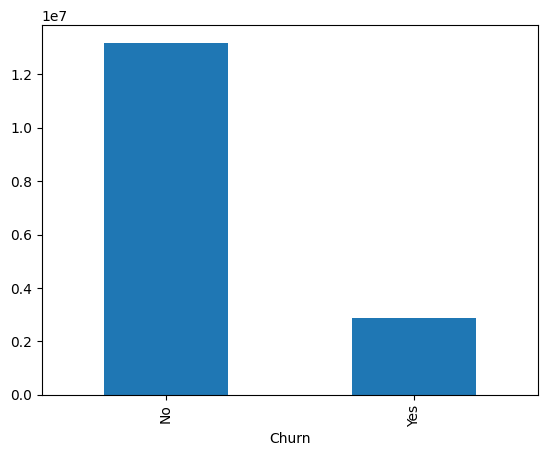

In [123]:
ChargesXChern.plot(kind='bar') # obvious that customers with more totalcharges are satisfied more with the business so they stick around longer

In [173]:
paymentXChurn = pd.crosstab(df['PaymentMethod'],df['Churn'])

In [176]:
paymentXChurn.sort_values('No',ascending=False)

Churn,No,Yes
PaymentMethod,,
Mailed check,1296,308
Electronic check,1294,1071
Credit card (automatic),1289,232
Bank transfer (automatic),1284,258


<Axes: xlabel='PaymentMethod'>

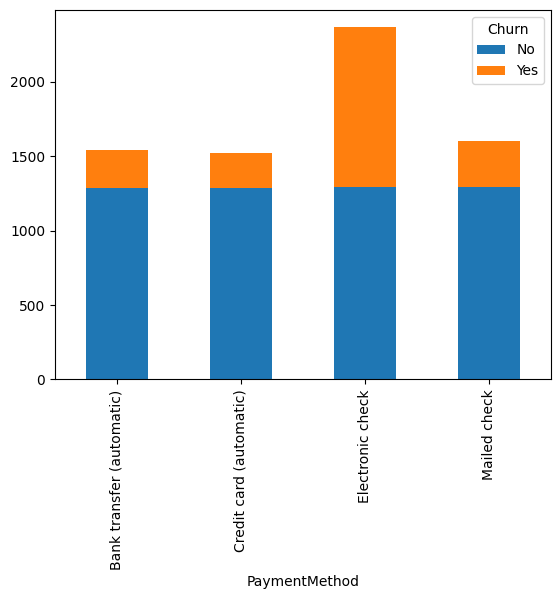

In [177]:
paymentXChurn.plot(kind = 'bar',stacked=True)

In [183]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

### Let's simplify the process

In [188]:
def stacked_barChart_with_Churn(col):
    colXChurn = pd.crosstab(df[col],df['Churn'])
    colXChurn.plot(kind='bar',stacked=True)

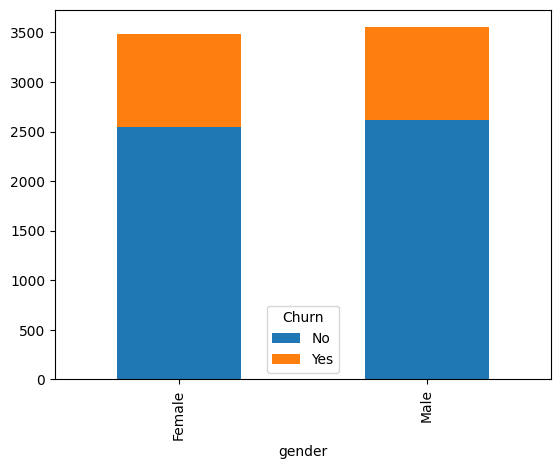

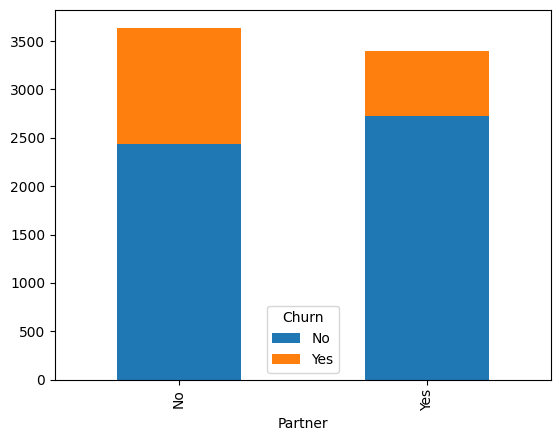

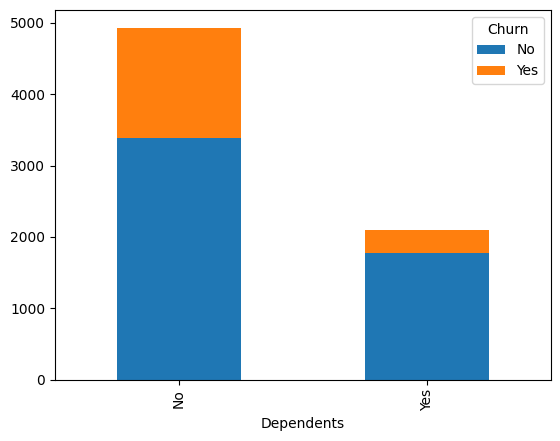

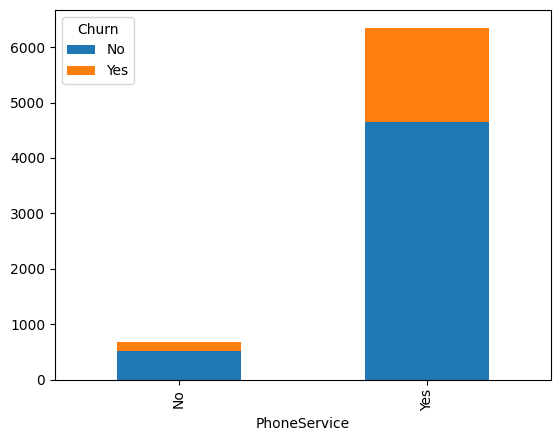

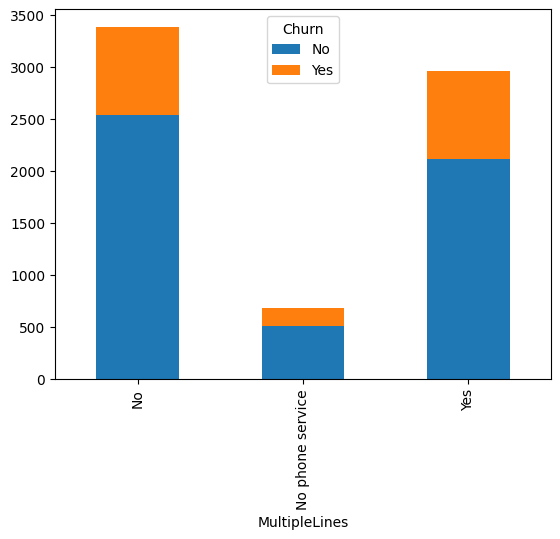

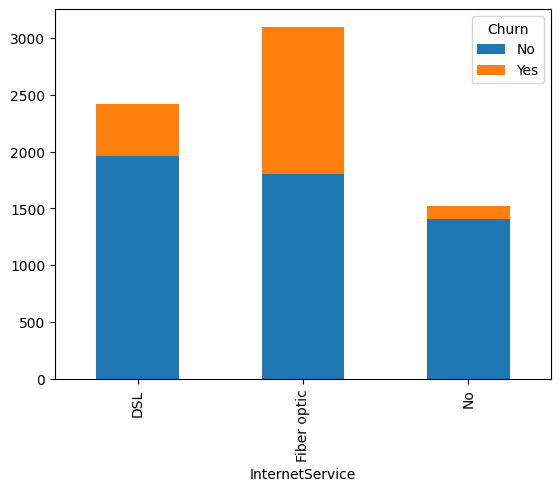

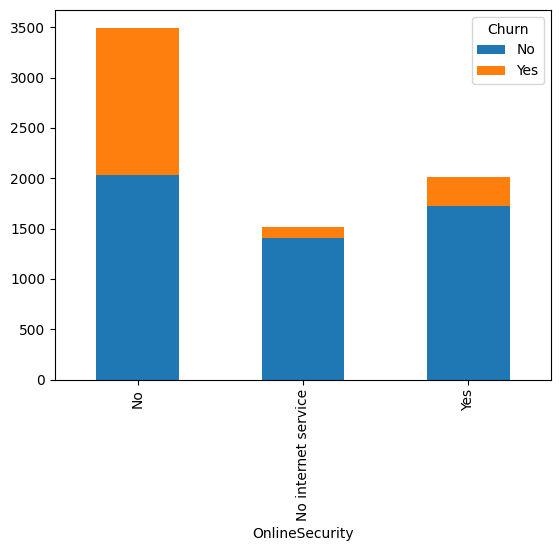

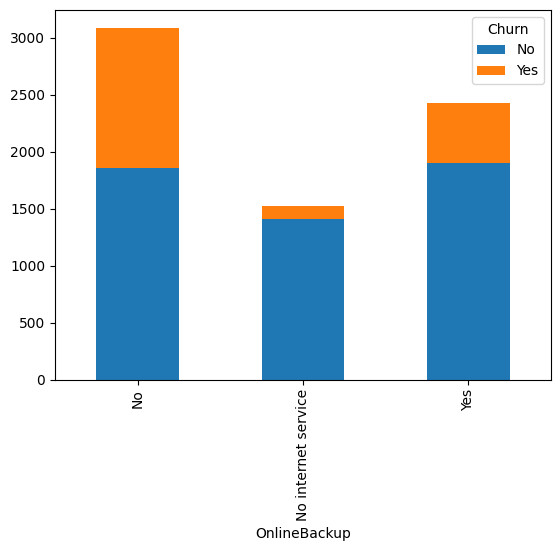

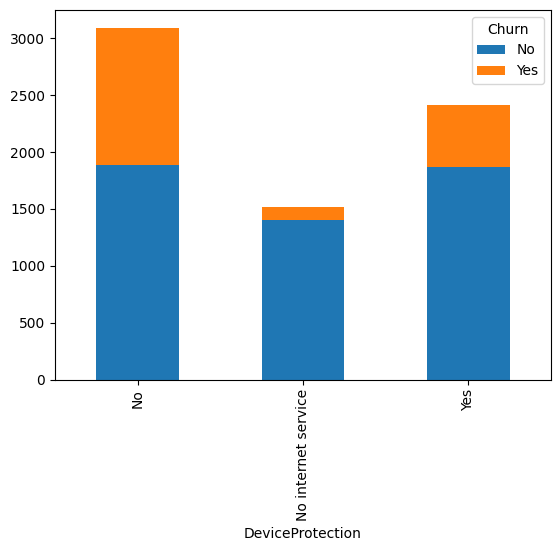

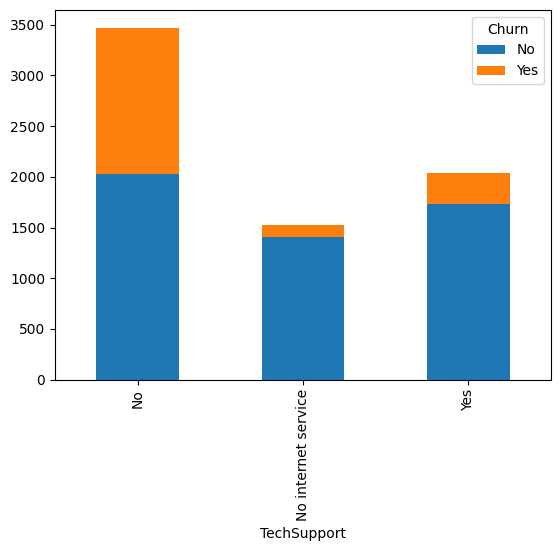

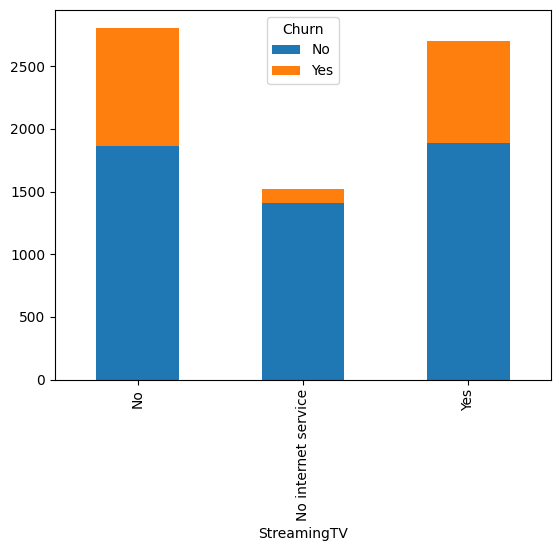

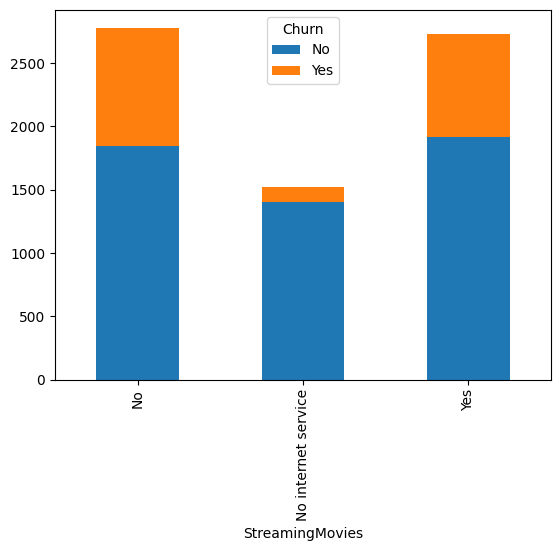

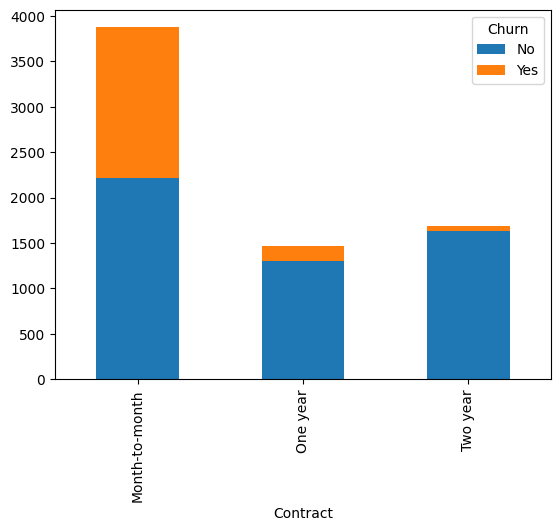

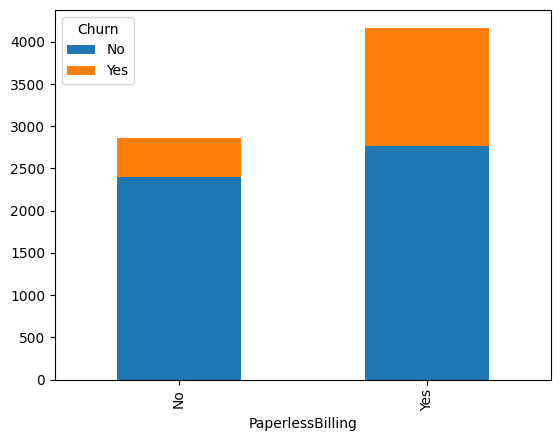

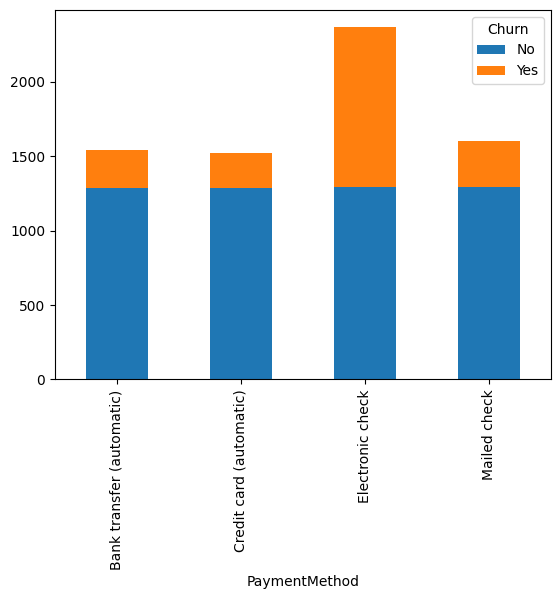

In [191]:
for cols in df.columns:
    if df[cols].dtype not in ['int','float'] and cols not in ['customerID','Churn']:
        stacked_barChart_with_Churn(cols)

In [187]:
for i in df.columns:
    print(i) if df[i].dtype in ['int','float'] else "no"

SeniorCitizen
tenure
MonthlyCharges
TotalCharges


### let's move to numeric EDA now

<Axes: ylabel='Frequency'>

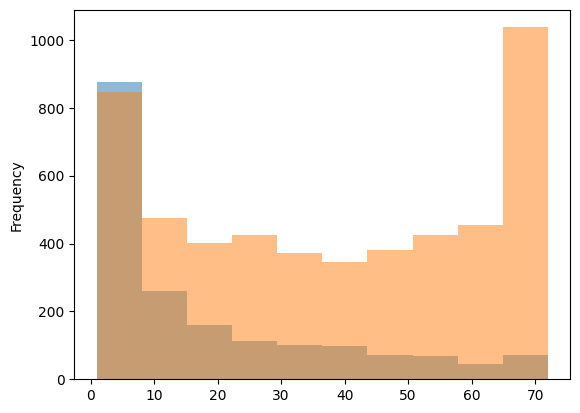

In [200]:
# tenure is a column which represents the number of months a customer has been with the company
df[df['Churn'] == 'Yes']['tenure'].plot(kind='hist', alpha=0.5)
df[df['Churn'] == 'No']['tenure'].plot(kind='hist', alpha=0.5)


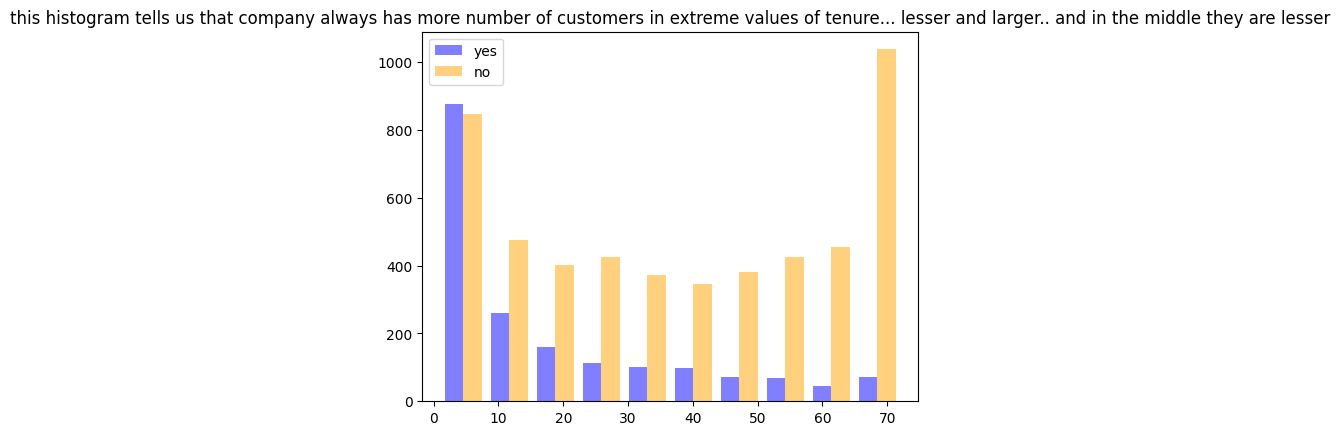

In [216]:
churn_yes = df[df['Churn'] == 'Yes']['tenure']
churn_no = df[df['Churn'] == 'No']['tenure']

plt.hist([churn_yes,churn_no],bins=10,alpha=0.5,label= ['yes','no'],color=['blue','orange'],stacked=False)
plt.legend()
plt.title('this histogram tells us that company always has more number of customers in extreme values of tenure... lesser and larger.. and in the middle they are lesser')
plt.show()



<Axes: >

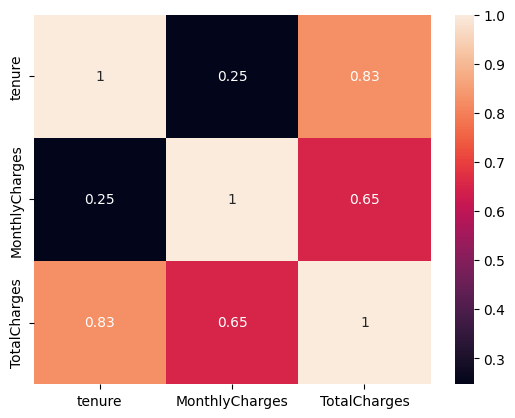

In [219]:
import seaborn as sns
corr = df[['tenure','MonthlyCharges','TotalCharges']].corr()
sns.heatmap(corr,annot=True)

# Data Pre-Processing

In [220]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [228]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,StandardScaler
from sklearn.model_selection import train_test_split

In [229]:
df.shape

(7032, 21)

In [259]:
X = df.drop(['customerID','Churn','TotalCharges'],axis=1) # removing customerID and TotalCharges as well because they ain't useful in training.. customer ID is absolute mess and totalcharges is derived from tenure and monthlycharges... causes multicollinearity if not removed.
y = df['Churn'].map({'No':0,'Yes':1})



In [272]:
y

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7032, dtype: int64

In [260]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)



In [274]:
X_train.gender

1413      Male
7003      Male
3355    Female
4494      Male
3541    Female
         ...  
3451      Male
5123    Female
4135    Female
4249    Female
1505      Male
Name: gender, Length: 5625, dtype: object

In [261]:
X_test.shape

(1407, 18)

In [262]:
numerics = X_train.select_dtypes(include=['int64','float64']).columns
categoricals = X_train.select_dtypes(include=['object']).columns

trans = ColumnTransformer([
    ('cat',OneHotEncoder(handle_unknown = 'ignore',drop = 'first'),categoricals),
    ('num',StandardScaler(),numerics)
])

In [263]:
X_train_trans = trans.fit_transform(X_train)

In [264]:
X_test_trans = trans.transform(X_test)

# Trainig

In [267]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier
from sklearn.svm import SVC

In [290]:
from sklearn.metrics import accuracy_score, classification_report, recall_score,roc_auc_score

In [300]:
models = [(LogisticRegression(),'lr'),(DecisionTreeClassifier(max_depth=4),'dt'),(RandomForestClassifier(n_estimators=500,class_weight='balanced'),'rf'),(AdaBoostClassifier(),'ada'),(SVC(probability=True),'svc')]

In [301]:
for model,name in models:
    trained = model.fit(X_train_trans,y_train)
    y_pred = trained.predict(X_test_trans)
    y_prob = trained.predict_proba(X_test_trans)[:,1]
    rec = recall_score(y_test,y_pred)
    acc = accuracy_score(y_test,y_pred)
    auc = roc_auc_score(y_test,y_prob)
    
    print(name,": ")
    print(f"Accuracy: {acc} --- Recall: {rec} --- ROC-AUC: {auc}")
    print("="*95)

lr : 
Accuracy: 0.8031272210376688 --- Recall: 0.5748663101604278 --- ROC-AUC: 0.833640919185592
dt : 
Accuracy: 0.783226723525231 --- Recall: 0.5 --- ROC-AUC: 0.8197853197426115
rf : 
Accuracy: 0.7803837953091685 --- Recall: 0.48663101604278075 --- ROC-AUC: 0.8141620636638005
ada : 
Accuracy: 0.7938877043354655 --- Recall: 0.4919786096256685 --- ROC-AUC: 0.8397145534267566
svc : 
Accuracy: 0.7924662402274343 --- Recall: 0.4839572192513369 --- ROC-AUC: 0.7903528479947819
